<a href="https://colab.research.google.com/github/saim9211/Machine-Learning-Stuff/blob/main/imbalanced_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import kagglehub
path = kagglehub.dataset_download("arashnic/imbalanced-data-practice")

100%|██████████| 6.68M/6.68M [00:00<00:00, 113MB/s]

Extracting files...


In [2]:
import os
import pandas as pd

if os.path.isdir(path):
    files = os.listdir(path)
    csv_files = [f for f in files if f.endswith('.csv')]

    if csv_files:
        # Assuming the first CSV file is the one to be loaded
        file_to_load = os.path.join(path, csv_files[0])
        df = pd.read_csv(file_to_load)
        print("DataFrame loaded successfully:")
        print(df.head())
    else:
        print(f"No CSV files found in the directory: {path}")
        print(f"Files found: {files}")
else:
    print(f"The path '{path}' is not a directory or does not exist.")

DataFrame loaded successfully:
       id  Gender  Age  Driving_License  Region_Code  Previously_Insured  \
0  167647    Male   22                1          7.0                   1   
1   17163    Male   42                1         28.0                   0   
2   32023  Female   66                1         33.0                   0   
3   87447  Female   22                1         33.0                   0   
4  501933    Male   28                1         46.0                   1   

  Vehicle_Age Vehicle_Damage  Annual_Premium  Policy_Sales_Channel  Vintage  \
0    < 1 Year             No          2630.0                 152.0       16   
1    1-2 Year            Yes         43327.0                  26.0      135   
2    1-2 Year            Yes         35841.0                 124.0      253   
3    < 1 Year             No         27645.0                 152.0       69   
4    < 1 Year             No         29023.0                 152.0      211   

   Response  
0         0  
1        

In [3]:
df.sample(3)

,id,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage,Response
112678,32991,Male,41,1,46.0,0,1-2 Year,Yes,27133.0,124.0,221,0
78646,214837,Male,23,1,46.0,1,< 1 Year,No,27982.0,152.0,75,0
315727,300431,Male,42,1,28.0,0,1-2 Year,Yes,38864.0,26.0,200,1


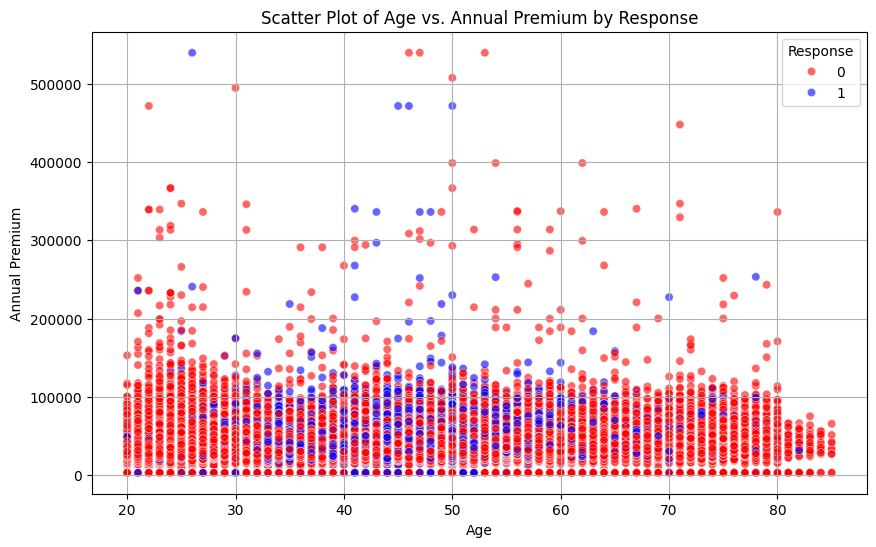

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Age', y='Annual_Premium', hue='Response', palette={0: 'red', 1: 'blue'}, alpha=0.6)
plt.title('Scatter Plot of Age vs. Annual Premium by Response')
plt.xlabel('Age')
plt.ylabel('Annual Premium')
plt.grid(True)
plt.legend(title='Response', loc='best')
plt.show()

#undersampling technique


Shape of original DataFrame: (382154, 12)
Shape of resampled DataFrame: (125202, 12)
Distribution of 'Response' in original data:
 Response
0    319553
1     62601
Name: count, dtype: int64
Distribution of 'Response' in resampled data:
 Response
0    62601
1    62601
Name: count, dtype: int64


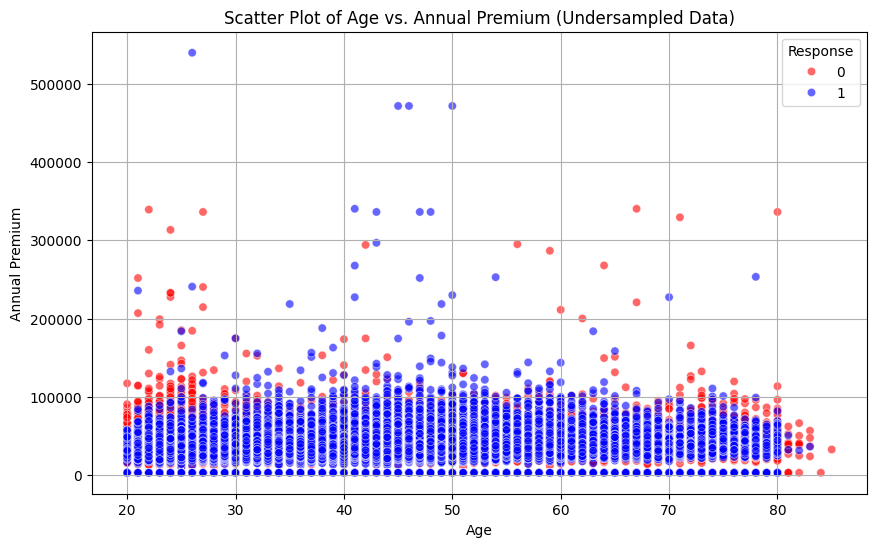

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.under_sampling import RandomUnderSampler
import pandas as pd

# Prepare the data for undersampling
# Drop 'id' and 'Response' from features (X)
# 'Gender', 'Vehicle_Age', 'Vehicle_Damage' are categorical, need encoding
X = df.drop(columns=['id', 'Response'])
y = df['Response']

# One-hot encode categorical features
X_encoded = pd.get_dummies(X, columns=['Gender', 'Vehicle_Age', 'Vehicle_Damage'], drop_first=True)

# Apply Random Under-sampling
rus = RandomUnderSampler(random_state=42)
X_resampled, y_resampled = rus.fit_resample(X_encoded, y)

# Create a DataFrame from the resampled data for plotting
df_resampled = X_resampled.copy()
df_resampled['Response'] = y_resampled

print("Shape of original DataFrame:", df.shape)
print("Shape of resampled DataFrame:", df_resampled.shape)
print("Distribution of 'Response' in original data:\n", y.value_counts())
print("Distribution of 'Response' in resampled data:\n", y_resampled.value_counts())

# Generate scatter plot for the undersampled data
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_resampled, x='Age', y='Annual_Premium', hue='Response', palette={0: 'red', 1: 'blue'}, alpha=0.6)
plt.title('Scatter Plot of Age vs. Annual Premium (Undersampled Data)')
plt.xlabel('Age')
plt.ylabel('Annual Premium')
plt.grid(True)
plt.legend(title='Response', loc='best')
plt.show()

#over sampling technique

Shape of original DataFrame: (382154, 12)
Shape of newly oversampled DataFrame: (639106, 12)
Distribution of 'Response' in original data:
 Response
0    319553
1     62601
Name: count, dtype: int64
Distribution of 'Response' in newly oversampled data:
 Response
0    319553
1    319553
Name: count, dtype: int64


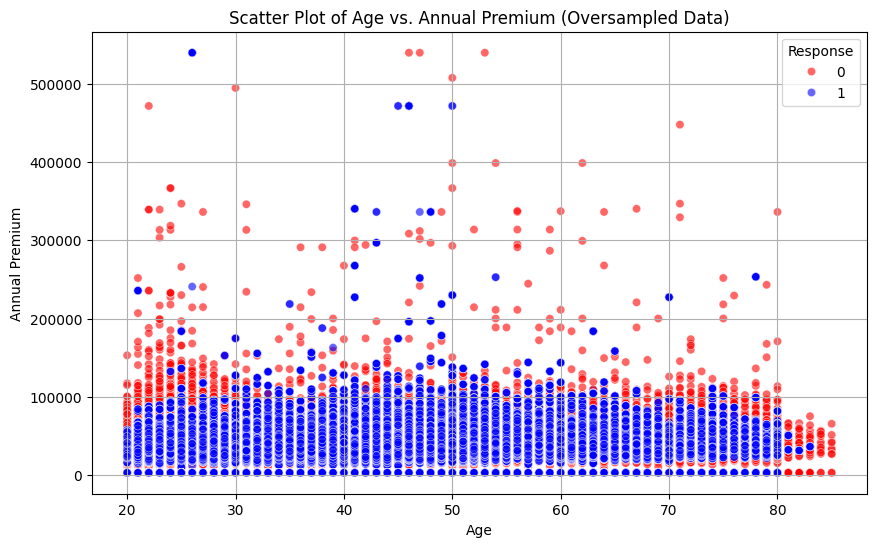

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.over_sampling import RandomOverSampler # Corrected import for oversampling
import pandas as pd

# Prepare the data for oversampling (re-using X_encoded and y from previous steps)
# Ensure X_encoded and y are correctly defined from the original dataframe.
# If not, recreate them as:
# X = df.drop(columns=['id', 'Response'])
# y = df['Response']
# X_encoded = pd.get_dummies(X, columns=['Gender', 'Vehicle_Age', 'Vehicle_Damage'], drop_first=True)

# Apply Random Over-sampling
ros = RandomOverSampler(random_state=42) # Changed to RandomOverSampler
X_oversampled, y_oversampled = ros.fit_resample(X_encoded, y)

# Create a DataFrame from the oversampled data for plotting
df_oversampled = X_oversampled.copy()
df_oversampled['Response'] = y_oversampled

print("Shape of original DataFrame:", df.shape)
print("Shape of newly oversampled DataFrame:", df_oversampled.shape)
print("Distribution of 'Response' in original data:\n", y.value_counts())
print("Distribution of 'Response' in newly oversampled data:\n", y_oversampled.value_counts())

# Generate scatter plot for the oversampled data
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_oversampled, x='Age', y='Annual_Premium', hue='Response', palette={0: 'red', 1: 'blue'}, alpha=0.6)
plt.title('Scatter Plot of Age vs. Annual Premium (Oversampled Data)') # Updated title
plt.xlabel('Age')
plt.ylabel('Annual Premium')
plt.grid(True)
plt.legend(title='Response', loc='best')
plt.show()

#smote analysis with the points between sample and neighbour

Shape of original DataFrame: (382154, 12)
Shape of SMOTE DataFrame: (639106, 12)
Distribution of 'Response' in original data:
 Response
0    319553
1     62601
Name: count, dtype: int64
Distribution of 'Response' in SMOTE data:
 Response
0    319553
1    319553
Name: count, dtype: int64


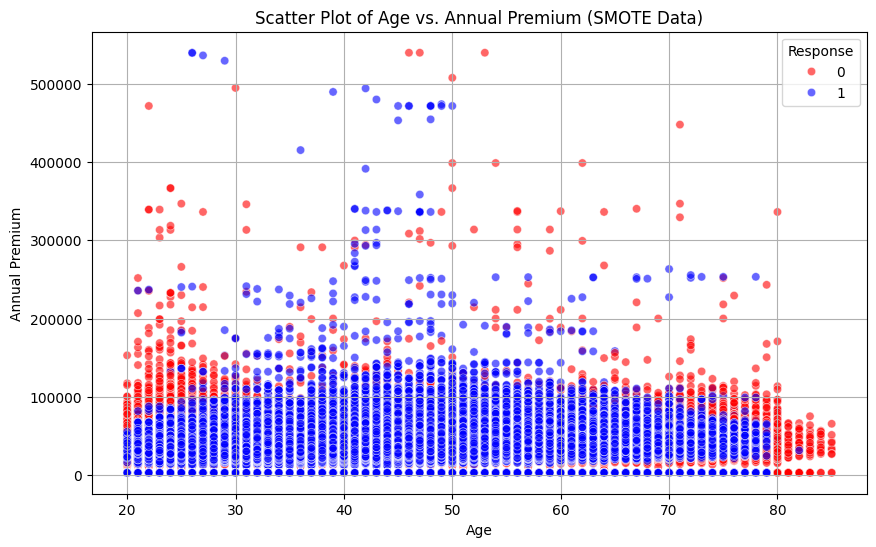

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.over_sampling import SMOTE
import pandas as pd

# Apply SMOTE
sm = SMOTE(random_state=42)
X_smoted, y_smoted = sm.fit_resample(X_encoded, y)

# Create a DataFrame from the SMOTE data for plotting
df_smoted = X_smoted.copy()
df_smoted['Response'] = y_smoted

print("Shape of original DataFrame:", df.shape)
print("Shape of SMOTE DataFrame:", df_smoted.shape)
print("Distribution of 'Response' in original data:\n", y.value_counts())
print("Distribution of 'Response' in SMOTE data:\n", y_smoted.value_counts())

# Generate scatter plot for the SMOTE data
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_smoted, x='Age', y='Annual_Premium', hue='Response', palette={0: 'red', 1: 'blue'}, alpha=0.6)
plt.title('Scatter Plot of Age vs. Annual Premium (SMOTE Data)')
plt.xlabel('Age')
plt.ylabel('Annual Premium')
plt.grid(True)
plt.legend(title='Response', loc='best')
plt.show()